# Baseline Model and Validation Strategy

In this notebook, we demonstrate the validation strategy and evaluate a naive baseline model. We also compare the performance of models enhanced with time-series decomposition components computed using different methods.

The validation pipeline logs model metrics and saves the corresponding code in `.py` files using mlflow. The validation scripts are located in `src/validation/`.

To evaluate model performance, we split the dataset into several test sets using a **rolling time-based validation scheme**. For each test set, the model is trained on all available previous months and used to predict sales for the following month.

The baseline model is located in `src/models/`. It predicts the sales of an item in a shop using the sales from the previous month. If the item was not sold in the previous month, the model predicts `0`.

---

## 1. Imports

In [ ]:
from pathlib import Path

import pandas as pd
import mlflow
from sklearn.metrics import root_mean_squared_error


from src.data.etl import (
    ItemCategoryLoader,
    ItemsLoader,
    ShopsLoader,
    TrainLoader,
    DfFinalLoader,
    ForSubmissionLoader,
)

from src.models.baseline_model import BaseLineModel, ZerosModel, OnesModel, SeasonalModel, StatsSeasonalModel, CategorySeasonalModel, ShopCatTrendModel
from src.validation.chema import validation_chema, log_validation
from src.visualization.plot_functions import plot_time_dataframe

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Predict Future Sales")

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: http://127.0.0.1:5000


## 2. Data loading

In [3]:
project_root = Path.cwd().parent
raw_path = project_root / "data" / "raw"
processed_path = project_root / "data" / "processed"
models_path = project_root / "data" / "models" / "validation"

items_df = ItemsLoader(raw_data_path=raw_path, cache_path=processed_path).load()
item_cats_df = ItemCategoryLoader(raw_data_path=raw_path, cache_path=processed_path).load()
shops_df = ShopsLoader(raw_data_path=raw_path, cache_path=processed_path).load()
train_df = TrainLoader(raw_data_path=raw_path, cache_path=processed_path).load()
final_df = DfFinalLoader(cache_path=processed_path, shops=shops_df, items=items_df, item_cats=item_cats_df, train=train_df).load()
subm_df = ForSubmissionLoader(raw_data_path=raw_path, cache_path=processed_path, shops=shops_df, items=items_df).load()


## 3. Model creation



To evaluate model performance, we implement two time-series cross-validation schemes:

The first one is expanding window starting from the first month.

The second one is a 2-year window that moves forward.

First lets create models with constant prediction to see if baseline is any better

In [20]:
zeros_results = log_validation(final_df, ZerosModel, models_path, start=0)
zeros_results_24 = log_validation(final_df, ZerosModel, models_path, start=0, window_size=24)

C:\Users\user\predict-future-sales\src\validation\chema.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  valid['item_cnt_day'] = prediction


🏃 View run ZerosModel at: http://127.0.0.1:5000/#/experiments/1/runs/1b5fbaa8e8c3420fa0f9b63a32c877a3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  valid['item_cnt_day'] = prediction


🏃 View run ZerosModel at: http://127.0.0.1:5000/#/experiments/1/runs/e84bb21a8e91497eb0d0777040aa8f7d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [7]:
ones_results = log_validation(final_df, OnesModel, models_path, start=0)
ones_results_24 = log_validation(final_df, OnesModel, models_path, start=0, window_size=24)

C:\Users\user\predict-future-sales\src\validation\chema.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid[['date_block_num', 'date', 'corrected_shop_id', 'corrected_item_id', 'item_cnt_day', 'true_ans']]], ignore_index=True)


🏃 View run OnesModel at: http://127.0.0.1:5000/#/experiments/1/runs/a71eee77e230438f9224d14200ccee13
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid[['date_block_num', 'date', 'corrected_shop_id', 'corrected_item_id', 'item_cnt_day', 'true_ans']]], ignore_index=True)


🏃 View run OnesModel at: http://127.0.0.1:5000/#/experiments/1/runs/c0ecff32d2de4ad7a0bf202c64047e6d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Baseline model that just repeats sales from previous month and gives zeros if this item wasnt sold in this store last month

In [9]:
baseline_results = log_validation(final_df, BaseLineModel, models_path)
baseline_results_24 = log_validation(final_df, BaseLineModel, models_path, window_size=24)

C:\Users\user\predict-future-sales\src\validation\chema.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid[['date_block_num', 'date', 'corrected_shop_id', 'corrected_item_id', 'item_cnt_day', 'true_ans']]], ignore_index=True)


🏃 View run BaseLineModel at: http://127.0.0.1:5000/#/experiments/1/runs/860bb9dd67ca4ddba1561e2fcf22ccc0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid[['date_block_num', 'date', 'corrected_shop_id', 'corrected_item_id', 'item_cnt_day', 'true_ans']]], ignore_index=True)


🏃 View run BaseLineModel at: http://127.0.0.1:5000/#/experiments/1/runs/2e8d77e711b34d33920b02cc66e73a4c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


This model is based on baseline but also calculates seasonal component for each item in each shop and adds it to the prediciton

In [10]:
seasonal_results = log_validation(final_df, SeasonalModel, models_path)
seasonal_results_24 = log_validation(final_df, SeasonalModel, models_path, window_size=24)

C:\Users\user\predict-future-sales\src\validation\chema.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid[['date_block_num', 'date', 'corrected_shop_id', 'corrected_item_id', 'item_cnt_day', 'true_ans']]], ignore_index=True)


🏃 View run SeasonalModel at: http://127.0.0.1:5000/#/experiments/1/runs/0e50c958330a45a9be2f20990ff696c4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid[['date_block_num', 'date', 'corrected_shop_id', 'corrected_item_id', 'item_cnt_day', 'true_ans']]], ignore_index=True)


🏃 View run SeasonalModel at: http://127.0.0.1:5000/#/experiments/1/runs/1417b273bcdb4ca3864067a5a4dac809
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


This model is the same as previous one, but calculates seasonal component using functions from statsmodel library

In [12]:
stats_model_seasonal_results = log_validation(final_df, StatsSeasonalModel, models_path)
stats_model_seasonal_results_24 = log_validation(final_df, StatsSeasonalModel, models_path, window_size=24)

C:\Users\user\predict-future-sales\src\validation\chema.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  valid['item_cnt_day'] = prediction


🏃 View run StatsSeasonalModel at: http://127.0.0.1:5000/#/experiments/1/runs/e86a10fa20574a1abec642bcecf37aa1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  valid['item_cnt_day'] = prediction


🏃 View run StatsSeasonalModel at: http://127.0.0.1:5000/#/experiments/1/runs/f0bf0af103db40b9ad2e5fb132b1f29e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


This model calculates seasonal component for each category using statsmodel and adds it to baseilne prediction

In [14]:
category_seasonal_results = log_validation(final_df, CategorySeasonalModel, models_path)
category_seasonal_results_24 = log_validation(final_df, CategorySeasonalModel, models_path, window_size=24)

C:\Users\user\predict-future-sales\src\validation\chema.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  valid['item_cnt_day'] = prediction


🏃 View run CategorySeasonalModel at: http://127.0.0.1:5000/#/experiments/1/runs/7982f11bbcd5451ba5933edb8ab6400f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  valid['item_cnt_day'] = prediction


🏃 View run CategorySeasonalModel at: http://127.0.0.1:5000/#/experiments/1/runs/bc68bf2ba86d4b1e9c4b37da05e4cf75
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


This model calculates trend component for each category in each shop using statsmodel and adds it to baseilne prediction

In [15]:
shop_cat_trend_results = log_validation(final_df, ShopCatTrendModel, models_path)
shop_cat_trend_results_24 = log_validation(final_df, ShopCatTrendModel, models_path, window_size=24)

C:\Users\user\predict-future-sales\src\validation\chema.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  valid['item_cnt_day'] = prediction


🏃 View run ShopCatTrendModel at: http://127.0.0.1:5000/#/experiments/1/runs/53b7f3a375894b6398cb62faa896353b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  valid['item_cnt_day'] = prediction


🏃 View run ShopCatTrendModel at: http://127.0.0.1:5000/#/experiments/1/runs/f6f7f8177c4144bea81b9864c775531a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## 4. Model comparison

We will use rmse as metric because it is used in competition and our goal is to optimize it.

In [16]:
def rmse_by_month(df):
    return df.groupby("date_block_num").apply(
        lambda x: root_mean_squared_error(x["true_ans"], x["item_cnt_day"])
    )

In [17]:
compare_df = pd.DataFrame({
    "ZerosModel": rmse_by_month(zeros_results),
    "OnesModel": rmse_by_month(ones_results),
    "BaseLineModel": rmse_by_month(baseline_results),
    "SeasonalModel": rmse_by_month(seasonal_results),
    "SeasonalStatsModel": rmse_by_month(stats_model_seasonal_results),
    "CategorySeasonalModel": rmse_by_month(category_seasonal_results),
    "ShopCatTrendModel": rmse_by_month(shop_cat_trend_results)
})

start_date = baseline_results['date'].iloc[0]
compare_df.index = pd.date_range(start=start_date, periods=len(compare_df), freq='MS').strftime('%Y-%m')
compare_df.mean()

C:\Users\user\AppData\Local\Temp\ipykernel_9160\945072317.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("date_block_num").apply(
C:\Users\user\AppData\Local\Temp\ipykernel_9160\945072317.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("date_block_num").apply(
C:\Users\user\AppData\Local\Temp\ipykernel_9160\945072317.py:2: FutureWarning: DataFrameGroupBy.apply operated on 

ZerosModel               8.519044
OnesModel                8.289650
BaseLineModel            6.609165
SeasonalModel            7.318750
SeasonalStatsModel       6.663762
CategorySeasonalModel    6.608546
ShopCatTrendModel        6.641315
dtype: float64

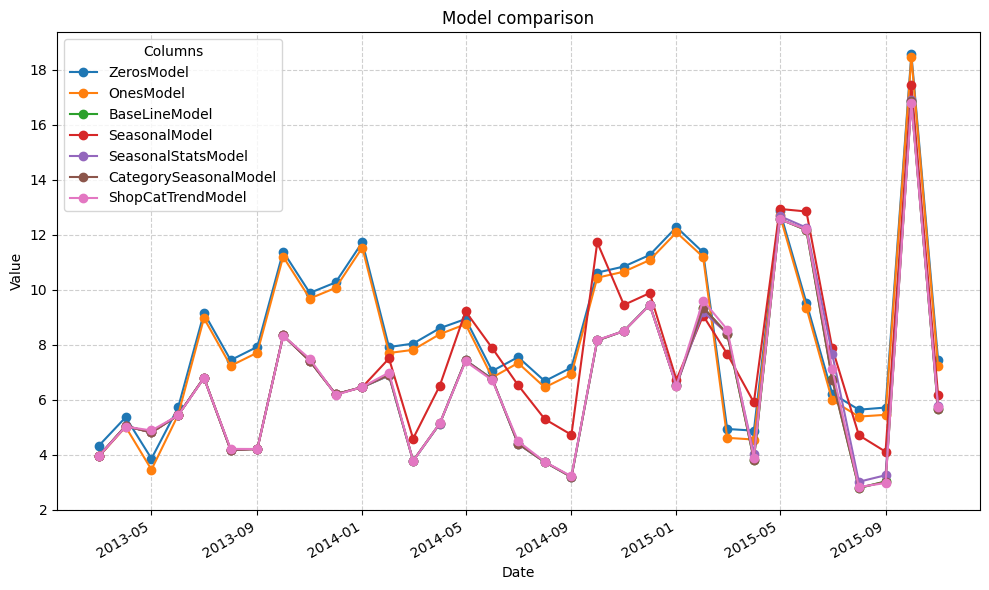

In [18]:
plot_time_dataframe(compare_df, 'Model comparison')

In [22]:
compare_24_df = pd.DataFrame({
    "ZerosModel": rmse_by_month(zeros_results_24),
    "OnesModel": rmse_by_month(ones_results_24),
    "BaseLineModel": rmse_by_month(baseline_results_24),
    "SeasonalModel": rmse_by_month(seasonal_results_24),
    "SeasonalStatsModel": rmse_by_month(stats_model_seasonal_results_24),
    "CategorySeasonalModel": rmse_by_month(category_seasonal_results_24),
    "ShopCatTrendModel": rmse_by_month(shop_cat_trend_results_24)
})

start_date_24 = baseline_results_24['date'].iloc[0]
compare_24_df.index = pd.date_range(start=start_date_24, periods=len(compare_24_df), freq='MS').strftime('%Y-%m')
compare_24_df.mean()

C:\Users\user\AppData\Local\Temp\ipykernel_9160\945072317.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("date_block_num").apply(
C:\Users\user\AppData\Local\Temp\ipykernel_9160\945072317.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("date_block_num").apply(
C:\Users\user\AppData\Local\Temp\ipykernel_9160\945072317.py:2: FutureWarning: DataFrameGroupBy.apply operated on 

ZerosModel               7.530880
OnesModel                7.269685
BaseLineModel            6.455915
SeasonalModel            8.155544
SeasonalStatsModel       6.472772
CategorySeasonalModel    6.451536
ShopCatTrendModel        6.483757
dtype: float64

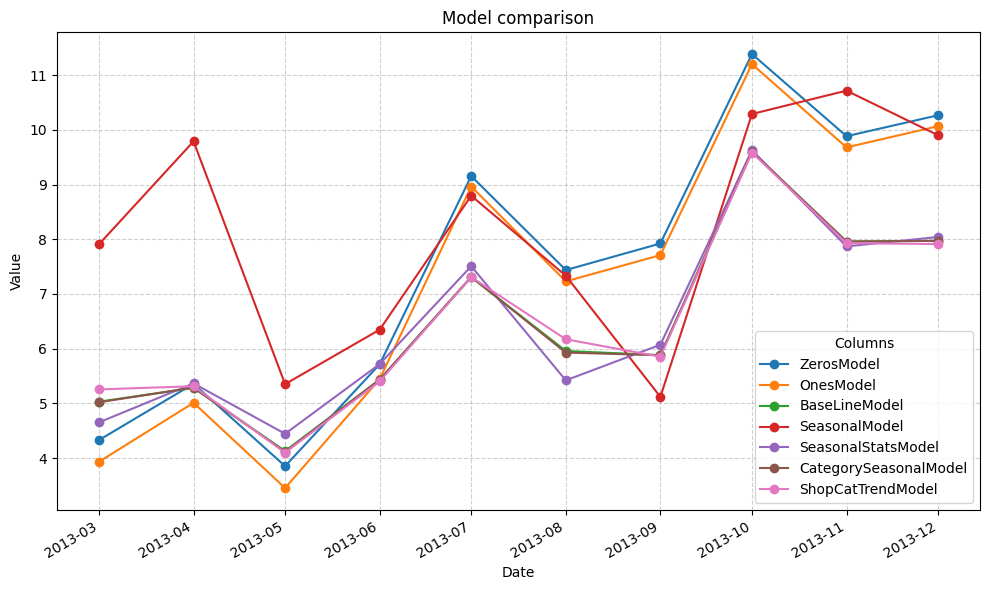

In [24]:
plot_time_dataframe(compare_24_df, 'Model comparison')

As we can see all of the models are better then constant predictions.

Most of the models are little worse then baseline due to how sparse sales are. Model that adds seasonal component of the category is slightly better because data becomes less sparced and has somewhat consistent values.

Also other combinations of trend and season in shops and categories were tested but no meaningfull results were achieved. Overall season and trend components may be usefull but because of the dataset they need a deeper work to show some result.